# Classification Example

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import balanced_accuracy_score, accuracy_score, precision_score, recall_score, make_scorer

# Validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

## Load Data

In [2]:
# Load the dataset directly from seaborn's datasets
df = sns.load_dataset('titanic')
df = df[['age', 'fare', 'embarked', 'sibsp', 'class', 'deck', 'alive']]
df.head()

,age,fare,embarked,sibsp,class,deck,alive
0,22.0,7.2500,S,1,Third,NaN,no
1,38.0,71.2833,C,1,First,C,yes
2,26.0,7.9250,S,0,Third,NaN,yes
3,35.0,53.1000,S,1,First,C,yes
4,35.0,8.0500,S,0,Third,NaN,no


In [3]:
df.shape

(891, 7)

In [4]:
df['alive'].value_counts()

alive
no     549
yes    342
Name: count, dtype: int64

## Feature Eng. Pipeline

In [5]:
# Canvia directament el target
df['alive'] = df['alive'].map({'yes': 1, 'no': 0})

In [6]:
# Cada Pipeline és una "recepta" de passos. Encara NO toquem les dades.

# Numèriques: només imputem amb la mediana
median_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# sibsp decidim imputar nuls amb 0
sibsp_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

# Categòriques SENSE ordre: imputem amb la moda + One-Hot
embarked_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

# Categòrica AMB ordre: imputem amb la moda + Ordinal (indicant l'ordre)
class_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['Third', 'Second', 'First']])),
])

# deck té molts nuls: imputem amb un valor constant "Unknown" + One-Hot
deck_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('median', median_pipeline, ['age', 'fare']),
        ('sibsp', sibsp_pipeline, ['sibsp']),
        ('embarked', embarked_pipeline, ['embarked']),
        ('class', class_pipeline, ['class']),
        ('deck', deck_pipeline, ['deck']),
    ],
    remainder='passthrough',  # deixa la resta de features tal i com estan
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('median', ...), ('sibsp', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

## Train / Test

In [8]:
X = df.drop('alive', axis=1)
y = df['alive']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

## Cross-validation

In [9]:
# Declare KFold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [10]:
# Declare scores to be used
scoring = {
    'Acc': make_scorer(accuracy_score),
    'Prec': make_scorer(precision_score),
    'Rec': make_scorer(recall_score)
}

In [11]:
def print_metrics(cv_results):
    for sc in scoring.keys():
        print(f'Train {sc}:', cv_results[f'train_{sc}'].mean().round(2))
    print()
    for sc in scoring.keys():
        print(f'Validation {sc}:', cv_results[f'test_{sc}'].mean().round(2))

## Baseline

In [12]:
from sklearn.dummy import DummyClassifier

In [13]:
bl = DummyClassifier(strategy='stratified')

bl_cv = cross_validate(
    bl,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(bl_cv)

Train Acc: 0.52
Train Prec: 0.38
Train Rec: 0.38

Validation Acc: 0.5
Validation Prec: 0.34
Validation Rec: 0.32


## Logistic Regression

In [14]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10_000))
])

lr_cv = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(lr_cv)

Train Acc: 0.73
Train Prec: 0.72
Train Rec: 0.49

Validation Acc: 0.73
Validation Prec: 0.73
Validation Rec: 0.5


## Decision Tree

In [15]:
from sklearn.tree import plot_tree

In [16]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(max_depth=2))
])

dt_cv = cross_validate(
    dt_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(dt_cv)

Train Acc: 0.73
Train Prec: 0.74
Train Rec: 0.48

Validation Acc: 0.73
Validation Prec: 0.72
Validation Rec: 0.47


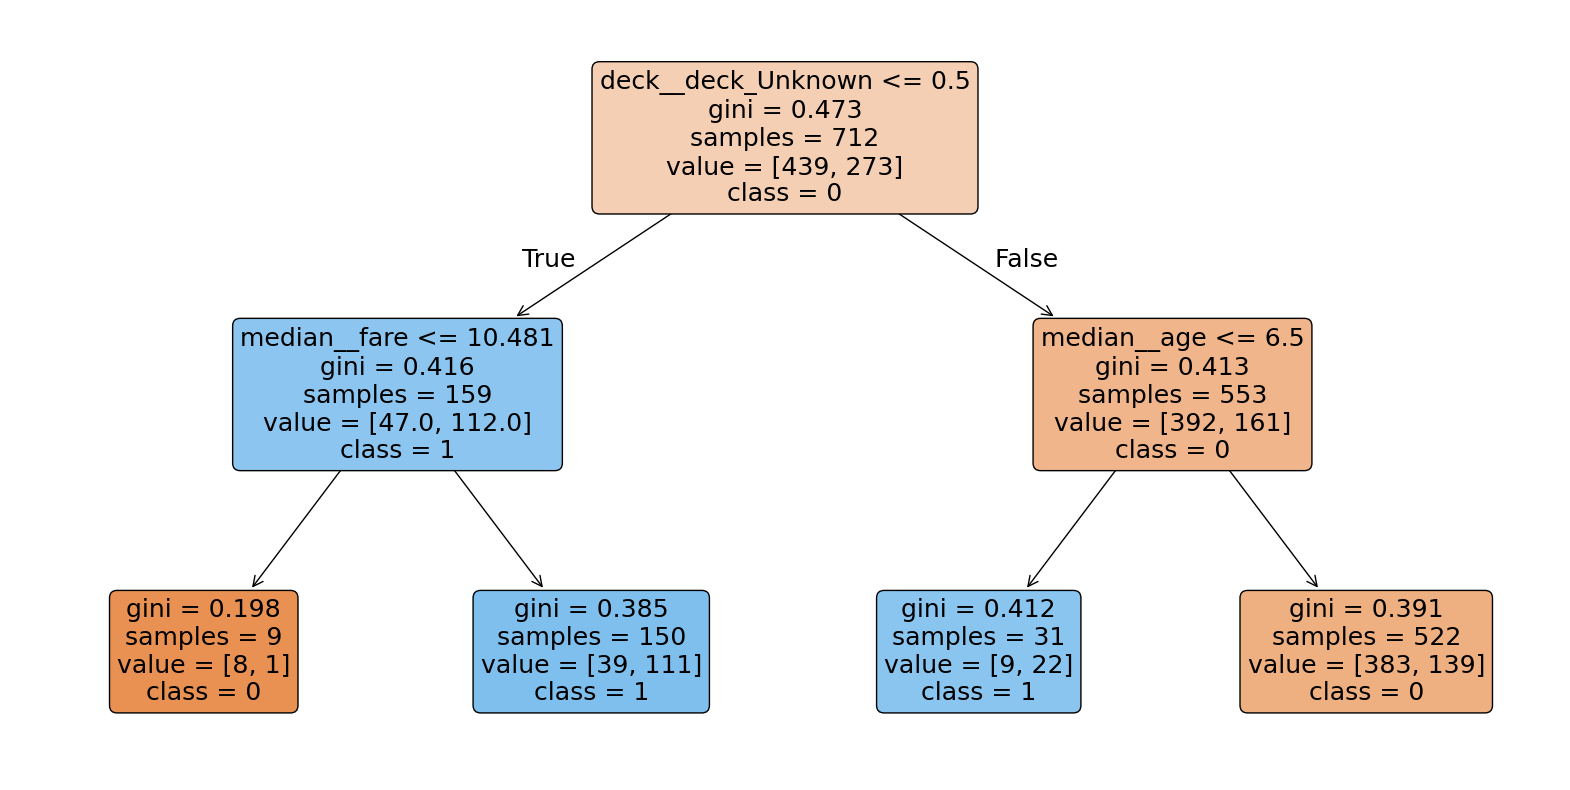

In [18]:
dt_pipeline.fit(X_train, y_train)
plt.figure(figsize=(20,10))
plot_tree(
    dt_pipeline['dt'],
    filled=True,
    feature_names=dt_pipeline['preprocessor'].get_feature_names_out(),
    class_names=['0', '1'],
    rounded=True
)
plt.show()

### Confusion Matrix Example

In [19]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

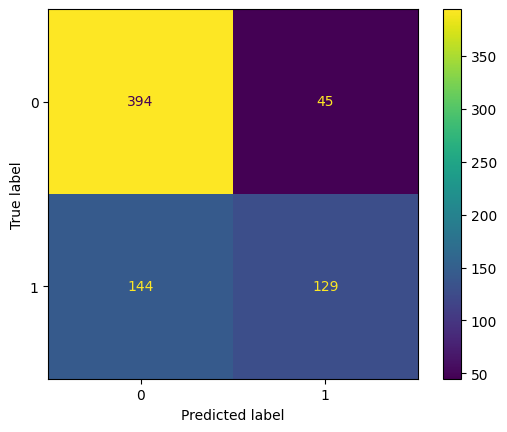

In [20]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(max_depth=5))
])

# cross_val_predict returns the predictions for each data point in the validation sets
val_preds = cross_val_predict(dt_pipeline, X_train, y_train, cv=kf)

cm = confusion_matrix(y_train, val_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)
disp.plot()
plt.show()

### Predicted Probabilities

`cross_val_predict()` function performs cross-validation and returns the predictions for each instance in the training set as if each instance were in a validation set:
- It splits the training data into multiple "folds" (validation sets).
- For each fold, it trains the model on the other folds (excluding the validation set).
- It then uses the model to make predictions on the validation set.
- Result: You get predictions for the entire training set, but importantly, the model never sees the instances it's predicting (they were always held out for validation during training).
- Returning probabilities: The `cross_val_predict()` function has an option to return class probabilities instead of just class predictions. You can enable this by setting `method="predict_proba"` in the function call. This provides the probabilities of each class for each instance, which can be useful when you want to assess the model's confidence in its predictions.

In [21]:
# This provides predictions for the entire training set, with each prediction made on data the model hasn’t seen during training
y_pred = cross_val_predict(dt_pipeline, X_train, y_train, cv=kf)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,

In [22]:
# This provides predicted probabilities for each class and instance on the entire training set,
# with each prediction made on data the model hasn’t seen during training
# For each row, it gives 2 probabilities: probability of class 0 and probability of class 1
y_pred_prob = cross_val_predict(dt_pipeline, X_train, y_train, cv=kf, method='predict_proba')
y_pred_prob

array([[0.57142857, 0.42857143],
       [0.65384615, 0.34615385],
       [0.25396825, 0.74603175],
       ...,
       [0.63302752, 0.36697248],
       [0.07692308, 0.92307692],
       [0.66071429, 0.33928571]], shape=(712, 2))

In [23]:
# Probability of class 1
y_prob1 = y_pred_prob[:, 1]
y_prob1

array([0.42857143, 0.34615385, 0.74603175, 0.24739583, 0.37007874,
       0.17216117, 0.1512605 , 1.        , 0.35632184, 0.1512605 ,
       0.        , 0.24739583, 0.        , 0.24739583, 0.1512605 ,
       0.74603175, 0.55263158, 0.1512605 , 0.        , 0.24739583,
       0.14285714, 0.67164179, 0.6       , 0.192     , 0.14035088,
       0.34188034, 0.192     , 0.23355263, 1.        , 0.14035088,
       0.15546218, 0.13664596, 0.73239437, 0.34615385, 0.34615385,
       0.15546218, 0.42201835, 0.192     , 0.34615385, 0.45454545,
       0.192     , 0.44444444, 0.35074627, 0.13664596, 0.23355263,
       0.15384615, 0.28571429, 0.17216117, 0.        , 0.55263158,
       0.192     , 0.6       , 0.        , 0.74603175, 0.92857143,
       0.46491228, 0.42857143, 0.23355263, 0.14035088, 0.35074627,
       0.36697248, 0.        , 0.7625    , 0.36697248, 0.35074627,
       0.92857143, 0.17216117, 0.14285714, 0.14035088, 0.7625    ,
       0.37007874, 0.23376623, 0.14285714, 0.37007874, 0.75   

In [24]:
# Prediction with threshold for the probability of class 1 > 80%
(y_prob1 >= 0.8).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [26]:
# With `predict` method, the decision threshold is 50% by default
dt_pipeline.fit(X_train, y_train)
print('Precision:', round(precision_score(y_test, dt_pipeline.predict(X_test)), 2))
print('Recall:', round(recall_score(y_test, dt_pipeline.predict(X_test)), 2))

Precision: 0.66
Recall: 0.3


In [27]:
y_test_prob1 = dt_pipeline.predict_proba(X_test)[:, 1]
d = {}

# Sweep across different threshold values and check how this affects precision and recall
for th in np.arange(0, 1.1, 0.1):
    y_test_pred = (y_test_prob1 >= th).astype(int)
    d[th] = {
        'precision': round(precision_score(y_test, y_test_pred), 2),
        'recall': round(recall_score(y_test, y_test_pred), 2)
    }

In [28]:
pd.DataFrame(d)

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
precision,0.39,0.40,0.40,0.59,0.65,0.64,0.66,0.66,0.82,0.82,0.82
recall,1.00,0.97,0.97,0.70,0.35,0.33,0.30,0.30,0.13,0.13,0.13
